# 📊 Pipeline de Avaliação — Corretor ENEM

Pipeline completo de benchmark: carrega as redações e gabaritos do `banco.sql`, executa OCR com **Gemini**, corrige com **Gemini 2.5 Flash**, calcula métricas (MAE por competência) e plota os resultados.

**Configuração necessária:** arquivo `.env` na raiz do projeto com `GEMINI_API_KEY`.

In [1]:
# Descomente a linha abaixo na primeira execução para instalar as dependências
# %pip install -q python-dotenv google-genai pandas matplotlib seaborn

import os
import re
import time
import datetime
import pandas as pd
from google import genai
from google.genai import types
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from pathlib import Path

print("✅ Imports OK")

✅ Imports OK


In [2]:
# Carrega variáveis do .env (raiz do projeto, um nível acima de notebooks/)
load_dotenv(dotenv_path=Path("..") / ".env", override=True)

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")
OCR_MODEL      = "gemini-2.5-flash"   # thinking_budget=0 suportado
LANGUAGE_MODEL = "gemini-2.5-flash"   # thinking_budget=0 suportado

# Preços Gemini 2.5 Flash sem thinking (USD por 1M tokens)
# https://ai.google.dev/gemini-api/docs/pricing
PRICE_INPUT_PER_1M  = 0.075
PRICE_OUTPUT_PER_1M = 0.30

def calc_custo_usd(tokens_in: int, tokens_out: int) -> float:
    return (tokens_in * PRICE_INPUT_PER_1M + tokens_out * PRICE_OUTPUT_PER_1M) / 1_000_000

if not GEMINI_API_KEY:
    raise EnvironmentError("❌ GEMINI_API_KEY não encontrada no .env")

# SDK google-genai — usa REST por padrão (sem gRPC)
client_gemini = genai.Client(api_key=GEMINI_API_KEY)

print("✅ Gemini configurado")
print(f"   OCR:      {OCR_MODEL}")
print(f"   Correção: {LANGUAGE_MODEL}")
print(f"   Preço input: ${PRICE_INPUT_PER_1M}/1M tokens | output: ${PRICE_OUTPUT_PER_1M}/1M tokens")

✅ Gemini configurado
   OCR:      gemini-2.5-flash
   Correção: gemini-2.5-flash
   Preço input: $0.075/1M tokens | output: $0.3/1M tokens


In [3]:
BANCO_SQL = Path("../data/banco.sql")
DATA_DIR  = Path("../data")


def carregar_banco_sql(caminho: Path) -> pd.DataFrame:
    """Parseia os INSERTs do banco.sql e retorna um DataFrame com o gabarito INEP."""
    with open(caminho, encoding="utf-8") as f:
        sql = f.read()
    padrao = r"\(\s*'([^']+)'\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*\)"
    matches = re.findall(padrao, sql)
    df = pd.DataFrame(
        matches,
        columns=["redacao", "inep_c1", "inep_c2", "inep_c3", "inep_c4", "inep_c5", "inep_total"]
    )
    for col in ["inep_c1", "inep_c2", "inep_c3", "inep_c4", "inep_c5", "inep_total"]:
        df[col] = df[col].astype(int)
    return df


def resolver_caminho_imagem(nome_arquivo: str):
    """Tenta .jpg e .jpeg para localizar o arquivo real na pasta data/."""
    for ext in [".jpg", ".jpeg"]:
        caminho = DATA_DIR / Path(nome_arquivo).with_suffix(ext).name
        if caminho.exists():
            return caminho
    return None


df_banco = carregar_banco_sql(BANCO_SQL)
df_banco["caminho"] = df_banco["redacao"].apply(resolver_caminho_imagem)

encontradas = df_banco["caminho"].notna().sum()
print(f"✅ {len(df_banco)} redações carregadas do banco")
print(f"   Imagens encontradas: {encontradas}/{len(df_banco)}")
df_banco[["redacao", "inep_c1", "inep_c2", "inep_c3", "inep_c4", "inep_c5", "inep_total"]].head()

✅ 15 redações carregadas do banco
   Imagens encontradas: 15/15


,redacao,inep_c1,inep_c2,inep_c3,inep_c4,inep_c5,inep_total
0,redacao_01.jpg,120,120,120,120,120,600
1,redacao_02.jpg,120,120,120,120,120,600
2,redacao_03.jpg,80,80,80,80,0,320
3,redacao_04.jpg,80,120,80,80,80,440
4,redacao_05.jpg,40,80,80,80,0,280


In [4]:
def ocr_gemini(caminho_imagem: Path) -> tuple[str, int, int]:
    """Extrai texto manuscrito. Retorna (texto, tokens_in, tokens_out)."""
    with open(caminho_imagem, "rb") as f:
        image_bytes = f.read()
    ext = Path(str(caminho_imagem)).suffix.lower()
    mime = "image/jpeg" if ext in (".jpg", ".jpeg") else "image/png"
    response = client_gemini.models.generate_content(
        model=OCR_MODEL,
        contents=[
            "Extraia todo o texto manuscrito da imagem com fidelidade máxima. "
            "Retorne apenas o texto extraído, sem comentários ou formatação adicional.",
            types.Part.from_bytes(data=image_bytes, mime_type=mime),
        ],
        config=types.GenerateContentConfig(
            thinking_config=types.ThinkingConfig(thinking_budget=0),
        ),
    )
    u = response.usage_metadata
    return response.text, (u.prompt_token_count or 0), (u.candidates_token_count or 0)


print(f"✅ Função ocr_gemini definida (modelo: {OCR_MODEL}, thinking desabilitado)")

✅ Função ocr_gemini definida (modelo: gemini-2.5-flash, thinking desabilitado)


In [ ]:
# ── Versão do prompt — mude aqui a cada iteração ──────────────────────────────
PROMPT_VERSION = "v2.2-c5-checklist"

PROMPT_CORRECAO = """\
<role>
Você é um corretor oficial de redações do ENEM com 15 anos de experiência, profundo conhecimento da Cartilha do Participante do ENEM e dos critérios oficiais do INEP. Sua avaliação é técnica, objetiva e estritamente alinhada ao espelho de correção oficial do INEP. Você não tem medo de atribuir a nota máxima (200) em cada competência se o texto cumprir os requisitos. Sua correção é justa e didática.
</role>

<task>
Corrija a redação abaixo avaliando cada uma das 5 competências do ENEM. Para cada competência, analise os elementos exigidos, liste as evidências do texto e, SOMENTE COMO CONCLUSÃO da sua análise, atribua uma nota seguindo OBRIGATORIAMENTE os níveis descritos na <grade_de_correcao>.
</task>

<grade_de_correcao>
Critérios oficiais INEP 2025. Enquadre o texto estritamente em um dos níveis abaixo:

### C1 – Demonstrar domínio da modalidade escrita formal da Língua Portuguesa
[OBS: Falha sintática engloba excesso, duplicação, ausência, frases fragmentadas ou siamesas]
- 0: Desconhecimento (estrutura sintática inexistente, independentemente da quantidade de desvios).
- 40: Domínio precário — estrutura sintática deficitária COM muitos desvios gramaticais frequentes.
- 80: Domínio insuficiente — estrutura sintática deficitária OU muitos desvios gramaticais.
- 120: Domínio mediano — estrutura sintática regular E alguns desvios gramaticais.
- 160: Domínio bom — estrutura sintática boa E poucos desvios gramaticais.
- 200: Domínio excelente — estrutura sintática excelente, no máximo 1 falha de estrutura E máximo 2 desvios gramaticais pontuais.

### C2 – Compreender a proposta e aplicar conceitos das várias áreas do conhecimento
- 0: Fuga total do tema.
- 40: Tangência do tema (aborda superficialmente ou de forma periférica).
- 80: Abordagem completa do tema E 2 partes do tema embrionárias (pouco desenvolvidas).
- 120: Abordagem completa E 1 parte embrionária E repertório não legitimado/pertinente OU abordagem completa E repertório legitimado e pertinente, mas SEM produtividade.
- 160: Abordagem completa E repertório legitimado, pertinente E produtivo (articulado ao tema).
- 200: Abordagem completa em 3 partes, nenhuma embrionária E repertório legitimado, pertinente e produtivo.

### C3 – Selecionar, relacionar, organizar e interpretar informações
- 40: Tangente ao tema e sem direção argumentativa.
- 80: Tangente ao tema com direção OU abordagem completa sem direção argumentativa.
- 120: Projeto de texto com muitas falhas e texto sem desenvolvimento adequado.
- 160: Projeto de texto com algumas falhas e desenvolvimento parcial (algumas lacunas).
- 200: Projeto de texto com poucas falhas e desenvolvimento da maior parte das informações OU projeto estratégico com desenvolvimento pleno.

### C4 – Demonstrar conhecimento dos mecanismos linguísticos necessários para a construção da argumentação
[OBS: Exige no mínimo 2 operadores argumentativos entre parágrafos para notas altas]
- 0: Não articula as informações.
- 40: Palavras e períodos justapostos e desconexos (sem coesão).
- 80: Presença rara de elementos coesivos / excessivas repetições / excessivas inadequações.
- 120: Presença pontual de elementos coesivos / algumas repetições / algumas inadequações.
- 160: Presença constante de elementos coesivos / poucas repetições / poucas inadequações.
- 200: Presença expressiva de elementos coesivos inter e intraparágrafos / raras repetições / sem inadequação.

### C5 – Elaborar proposta de intervenção para o problema abordado, respeitando os direitos humanos
- 0: Não apresenta proposta de intervenção ou apresenta proposta não relacionada ao tema ou ao assunto.
- 40: Apresenta proposta de intervenção vaga, precária ou relacionada apenas ao assunto.
- 80: Elabora, de forma insuficiente, proposta de intervenção relacionada ao tema, ou não articulada com a discussão desenvolvida no texto.
- 120: Elabora, de forma mediana, proposta de intervenção relacionada ao tema e articulada à discussão desenvolvida no texto.
- 160: Elabora bem proposta de intervenção relacionada ao tema e articulada à discussão desenvolvida no texto.
- 200: Elabora muito bem proposta de intervenção, detalhada, relacionada ao tema e articulada à discussão desenvolvida no texto.
[GUIA DE CALIBRAÇÃO C5] Para distinguir os níveis, responda as 5 perguntas abaixo sobre a proposta:
  1. AGENTE — a proposta cita explicitamente quem deve agir? (ex: governo, escola, mídia, família)
  2. AÇÃO — a proposta indica uma ação específica e concreta (além de "conscientizar" genérico)?
  3. MODO/MEIO — a proposta indica como a ação será executada (instrumento, método, canal)?
  4. EFEITO/FINALIDADE — a proposta apresenta a consequência esperada ou o objetivo?
  5. ARTICULAÇÃO — a proposta está diretamente conectada ao argumento central desenvolvido no texto?
→ Nenhum critério atendido = 0 | apenas 1 = 40 | 2 = 80 | 3-4 com articulação fraca = 120 | 4 com boa articulação = 160 | todos os 5 presentes e articulados = 200
</grade_de_correcao>

<output_format>
Responda estritamente neste formato Markdown:

## Correção da Redação

### Competência 1 – Domínio da Norma Culta
**Erros encontrados:** [cite trechos com erros e corrija-os]
**Análise:** [justifique o enquadramento na grade citando a regra específica do nível atribuído]
**Sugestão de melhoria:** [orientação prática]
**Nota Final C1:** [0/40/80/120/160/200]

### Competência 2 – Compreensão da Proposta e Repertório
**Repertório utilizado:** [identifique o repertório e classifique: legitimado? pertinente? produtivo?]
**Análise:** [justifique o enquadramento na grade]
**Análise:** [justifique o enquadramento na grade, indicando quantas partes do tema foram desenvolvidas e classificando o repertório]
**Nota Final C2:** [0/40/80/120/160/200]

### Competência 3 – Organização e Argumentação
**Estrutura identificada:** [descreva o projeto de texto: tese / argumentos / conclusão e aponte lacunas]
**Análise:** [justifique o enquadramento na grade com base na organização e autoria argumentativa]
**Análise:** [justifique o enquadramento na grade com base nas falhas do projeto de texto ou na estratégia argumentativa]
**Nota Final C3:** [0/40/80/120/160/200]

### Competência 4 – Coesão Textual
**Recursos coesivos encontrados:** [liste os operadores inter e intraparágrafos; aponte repetições e inadequações]
**Análise:** [justifique o enquadramento na grade; informe se há ao menos 2 operadores entre parágrafos]
**Sugestão de melhoria:** [orientação prática]
**Nota Final C4:** [0/40/80/120/160/200]

### Competência 5 – Proposta de Intervenção
**Proposta identificada:** [transcreva o trecho da proposta de intervenção]
**Checklist:**
  - Agente: ✅/❌ [quem]
  - Ação específica: ✅/❌ [o quê]
  - Modo/Meio: ✅/❌ [como]
  - Efeito/Finalidade: ✅/❌ [para quê]
  - Articulação com o texto: ✅/❌ [como se conecta ao argumento central]
**Análise:** [avalie a qualidade geral usando os critérios da grade: vaga/precária → 40, insuficiente/desarticulada → 80, mediana → 120, boa → 160, muito bem detalhada → 200]
**Sugestão de melhoria:** [orientação prática]
**Nota Final C5:** [0/40/80/120/160/200]

---

## Resultado Final

| Competência | Nota |
|-------------|------|
| C1 – Norma Culta | [nota] |
| C2 – Proposta e Repertório | [nota] |
| C3 – Argumentação | [nota] |
| C4 – Coesão | [nota] |
| C5 – Intervenção | [nota] |
| **TOTAL** | **[soma]** |

## Parecer Geral
[Parágrafo síntese com os principais pontos fortes e fracos da redação, e as 3 prioridades de melhoria mais importantes para o participante.]
</output_format>

<constraints>
- As notas devem ser OBRIGATORIAMENTE derivadas dos níveis descritos na <grade_de_correcao>.
- Nunca atribua nota fora dos valores oficiais: 0, 40, 80, 120, 160 ou 200.
- Se a redação fugir completamente do tema, a Competência 2 recebe nota 0 e as demais recebem no máximo 40.
- Se houver menos de 7 linhas, aplique as penalidades oficiais do INEP.
- Se houver desrespeito aos direitos humanos, a Competência 5 recebe nota 0.
- Cite sempre trechos reais da redação para embasar cada avaliação.
- Para C5, use o checklist de 5 critérios (agente, ação, modo, efeito, articulação) para calibrar o nível qualitativo — ele é um guia de raciocínio, não uma contagem mecânica.
</constraints>"""


_gemini_config = types.GenerateContentConfig(
    thinking_config=types.ThinkingConfig(thinking_budget=0),
)

# Notas válidas do ENEM
NOTAS_VALIDAS = {0, 40, 80, 120, 160, 200}


def _snap_nota(valor: int) -> int:
    """Arredonda para a nota válida mais próxima."""
    return min(NOTAS_VALIDAS, key=lambda n: abs(n - valor))


def corrigir_redacao(texto: str) -> tuple[str, int, int]:
    """Corrige a redação. Retorna (resposta, tokens_in, tokens_out)."""
    prompt_com_essay = PROMPT_CORRECAO + f"\n\n<essay>\n{texto}\n</essay>"
    resp = client_gemini.models.generate_content(
        model=LANGUAGE_MODEL,
        contents=prompt_com_essay,
        config=_gemini_config,
    )
    u = resp.usage_metadata
    return resp.text, (u.prompt_token_count or 0), (u.candidates_token_count or 0)


def extrair_notas(resposta: str) -> dict:
    """Extrai e valida notas. Cada C deve ser 0/40/80/120/160/200; total = soma (máx 1000)."""
    notas = {"ia_c1": 0, "ia_c2": 0, "ia_c3": 0, "ia_c4": 0, "ia_c5": 0, "ia_total": 0}
    if not resposta:
        return notas

    padroes_inline = {
        "ia_c1": r"\*?\*?Nota Final C1:\*?\*?\s*(\d+)",
        "ia_c2": r"\*?\*?Nota Final C2:\*?\*?\s*(\d+)",
        "ia_c3": r"\*?\*?Nota Final C3:\*?\*?\s*(\d+)",
        "ia_c4": r"\*?\*?Nota Final C4:\*?\*?\s*(\d+)",
        "ia_c5": r"\*?\*?Nota Final C5:\*?\*?\s*(\d+)",
    }
    padroes_tabela = {
        "ia_c1": r"\|\s*C1.*?\|\s*(\d+)\s*\|",
        "ia_c2": r"\|\s*C2.*?\|\s*(\d+)\s*\|",
        "ia_c3": r"\|\s*C3.*?\|\s*(\d+)\s*\|",
        "ia_c4": r"\|\s*C4.*?\|\s*(\d+)\s*\|",
        "ia_c5": r"\|\s*C5.*?\|\s*(\d+)\s*\|",
    }

    for col, pat in padroes_inline.items():
        m = re.search(pat, resposta, re.IGNORECASE)
        if m:
            notas[col] = _snap_nota(int(m.group(1)))

    for col, pat in padroes_tabela.items():
        if notas.get(col, 0) == 0:
            m = re.search(pat, resposta, re.IGNORECASE)
            if m:
                notas[col] = _snap_nota(int(m.group(1)))

    notas["ia_total"] = sum(notas[f"ia_c{i}"] for i in range(1, 6))
    return notas


print(f"✅ Prompt '{PROMPT_VERSION}' carregado — {len(PROMPT_CORRECAO)} chars")
print("✅ Funções corrigir_redacao e extrair_notas definidas")
print(f"   Validação ativa: notas em {sorted(NOTAS_VALIDAS)}, total ≤ 1000")

✅ Prompt 'v2.1-hibrido' carregado — 9017 chars
✅ Funções corrigir_redacao e extrair_notas definidas
   Validação ativa: notas em [0, 40, 80, 120, 160, 200], total ≤ 1000


In [6]:
# ── Pipeline Principal ────────────────────────────────────────────────────────
resultados = []

for _, row in df_banco.iterrows():
    nome    = row["redacao"]
    caminho = row["caminho"]

    print(f"🔄 {nome} ...", end=" ", flush=True)

    if caminho is None:
        print("❌ imagem não encontrada, pulando.")
        continue

    # 1. OCR
    try:
        t0 = time.time()
        texto, ocr_in, ocr_out = ocr_gemini(caminho)
        t_ocr = time.time() - t0
    except Exception as e:
        print(f"❌ OCR: {e}")
        continue

    # 2. Correção
    try:
        t0 = time.time()
        resposta, corr_in, corr_out = corrigir_redacao(texto)
        t_correcao = time.time() - t0
    except Exception as e:
        print(f"❌ Correção: {e}")
        continue

    custo_usd = calc_custo_usd(ocr_in + corr_in, ocr_out + corr_out)

    # 3. Extrai notas
    notas_ia = extrair_notas(resposta)

    resultados.append({
        "redacao":      nome,
        "inep_c1":      row["inep_c1"],
        "inep_c2":      row["inep_c2"],
        "inep_c3":      row["inep_c3"],
        "inep_c4":      row["inep_c4"],
        "inep_c5":      row["inep_c5"],
        "inep_total":   row["inep_total"],
        "texto_ocr":    texto[:300] + "...",
        "resposta_ia":  resposta,
        "t_ocr_s":      round(t_ocr, 2),
        "t_correcao_s": round(t_correcao, 2),
        "custo_usd":    round(custo_usd, 6),
        "tokens_in":    ocr_in + corr_in,
        "tokens_out":   ocr_out + corr_out,
        **notas_ia,
    })

    print(f"✅  INEP={row['inep_total']} | IA={notas_ia['ia_total']}  "
          f"[OCR {t_ocr:.1f}s | Correção {t_correcao:.1f}s | ${custo_usd:.4f}]")
    time.sleep(1)  # rate limit

df_resultados = pd.DataFrame(resultados)
print(f"\n📋 Pipeline concluído: {len(df_resultados)}/{len(df_banco)} redações processadas")

if len(df_resultados):
    custo_total = df_resultados["custo_usd"].sum()
    print(f"\n⏱️  Tempo médio por redação:")
    print(f"   OCR:      {df_resultados['t_ocr_s'].mean():.1f}s  (total {df_resultados['t_ocr_s'].sum():.0f}s)")
    print(f"   Correção: {df_resultados['t_correcao_s'].mean():.1f}s  (total {df_resultados['t_correcao_s'].sum():.0f}s)")
    print(f"\n💰 Custo total da run: ${custo_total:.4f} USD")
    print(f"   Custo médio por redação: ${custo_total/len(df_resultados):.4f} USD")

df_resultados[["redacao", "inep_total", "ia_total", "t_ocr_s", "t_correcao_s", "custo_usd"]].head(15)

🔄 redacao_01.jpg ... ✅  INEP=600 | IA=440  [OCR 4.0s | Correção 16.1s | $0.0013]
🔄 redacao_02.jpg ... ✅  INEP=600 | IA=440  [OCR 3.6s | Correção 16.2s | $0.0013]
🔄 redacao_03.jpg ... ✅  INEP=320 | IA=320  [OCR 5.0s | Correção 14.8s | $0.0012]
🔄 redacao_04.jpg ... ✅  INEP=440 | IA=360  [OCR 2.5s | Correção 16.6s | $0.0012]
🔄 redacao_05.jpg ... ✅  INEP=280 | IA=400  [OCR 4.2s | Correção 14.4s | $0.0013]
🔄 redacao_06.jpg ... ✅  INEP=360 | IA=240  [OCR 3.6s | Correção 14.3s | $0.0012]
🔄 redacao_07.jpg ... ✅  INEP=440 | IA=160  [OCR 3.3s | Correção 11.9s | $0.0011]
🔄 redacao_08.jpg ... ✅  INEP=160 | IA=320  [OCR 3.2s | Correção 13.4s | $0.0011]
🔄 redacao_09.jpg ... ✅  INEP=400 | IA=240  [OCR 4.1s | Correção 14.1s | $0.0013]
🔄 redacao_10.jpg ... ✅  INEP=400 | IA=360  [OCR 4.4s | Correção 17.9s | $0.0013]
🔄 redacao_11.jpg ... ✅  INEP=560 | IA=360  [OCR 4.1s | Correção 16.9s | $0.0015]
🔄 redacao_12.jpg ... ✅  INEP=400 | IA=320  [OCR 5.3s | Correção 20.5s | $0.0016]
🔄 redacao_13.jpg ... ✅  INEP

,redacao,inep_total,ia_total,t_ocr_s,t_correcao_s,custo_usd
0,redacao_01.jpg,600,440,4.02,16.14,0.001278
1,redacao_02.jpg,600,440,3.60,16.21,0.001300
2,redacao_03.jpg,320,320,4.96,14.79,0.001200
3,redacao_04.jpg,440,360,2.48,16.60,0.001226
4,redacao_05.jpg,280,400,4.19,14.41,0.001274
5,redacao_06.jpg,360,240,3.63,14.34,0.001190
6,redacao_07.jpg,440,160,3.32,11.95,0.001083
7,redacao_08.jpg,160,320,3.21,13.42,0.001119
8,redacao_09.jpg,400,240,4.13,14.05,0.001265
9,redacao_10.jpg,400,360,4.41,17.89,0.001335


In [7]:
# ── Métricas ──────────────────────────────────────────────────────────────────
for i in range(1, 6):
    df_resultados[f"erro_c{i}"] = abs(df_resultados[f"inep_c{i}"] - df_resultados[f"ia_c{i}"])

df_resultados["erro_total"] = abs(df_resultados["inep_total"] - df_resultados["ia_total"])

mae_total = df_resultados["erro_total"].mean()
mae_comps  = {f"C{i}": df_resultados[f"erro_c{i}"].mean() for i in range(1, 6)}

acertos_exatos = (df_resultados["erro_total"] == 0).sum()
taxa_acerto    = acertos_exatos / len(df_resultados) * 100

print(f"📊 RELATÓRIO DO BENCHMARK")
print(f"Modelo: {LANGUAGE_MODEL}")
print(f"Redações avaliadas: {len(df_resultados)}")
print(f"Acertos exatos (nota total): {acertos_exatos} ({taxa_acerto:.1f}%)")
print(f"\nMAE — Erro Absoluto Médio:")
print(f"  Total: {mae_total:.1f} pts")
for comp, err in mae_comps.items():
    print(f"  {comp}:    {err:.1f} pts")

📊 RELATÓRIO DO BENCHMARK
Modelo: gemini-2.5-flash
Redações avaliadas: 15
Acertos exatos (nota total): 2 (13.3%)

MAE — Erro Absoluto Médio:
  Total: 114.7 pts
  C1:    42.7 pts
  C2:    34.7 pts
  C3:    21.3 pts
  C4:    18.7 pts
  C5:    16.0 pts


/tmp/ipykernel_43230/3871587457.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comps, y=erros, ax=ax2, palette="viridis")


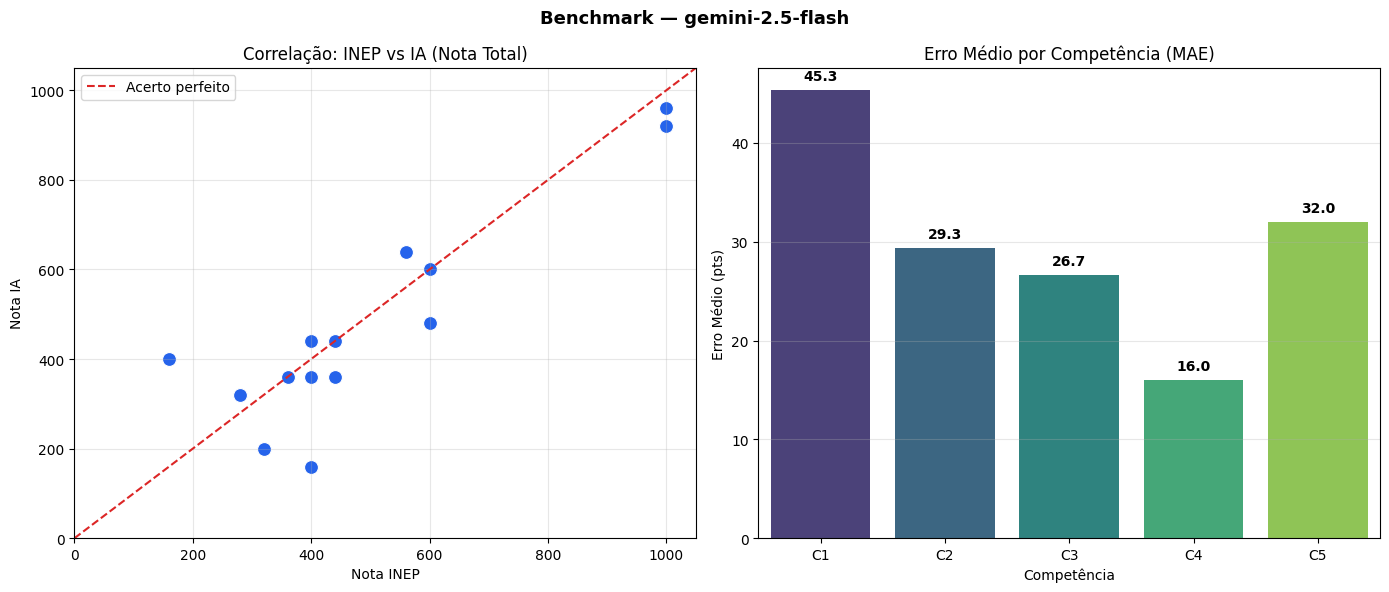

📈 Gráfico salvo em data/benchmark_plot.png


In [8]:
# ── Visualizações ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Benchmark — {LANGUAGE_MODEL}", fontsize=13, fontweight="bold")

# Gráfico 1: Dispersão nota total
sns.scatterplot(data=df_resultados, x="inep_total", y="ia_total", s=100, color="#2563eb", ax=ax1)
lim = max(df_resultados[["inep_total", "ia_total"]].max()) + 50
ax1.plot([0, lim], [0, lim], color="#dc2626", linestyle="--", label="Acerto perfeito")
ax1.set_title("Correlação: INEP vs IA (Nota Total)")
ax1.set_xlabel("Nota INEP"); ax1.set_ylabel("Nota IA")
ax1.set_xlim(0, lim); ax1.set_ylim(0, lim)
ax1.legend(); ax1.grid(True, alpha=0.3)

# Gráfico 2: MAE por competência
comps = list(mae_comps.keys())
erros = list(mae_comps.values())
sns.barplot(x=comps, y=erros, ax=ax2, palette="viridis")
ax2.set_title("Erro Médio por Competência (MAE)")
ax2.set_xlabel("Competência"); ax2.set_ylabel("Erro Médio (pts)")
ax2.grid(axis="y", alpha=0.3)
for i, v in enumerate(erros):
    ax2.text(i, v + 1, f"{v:.1f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../data/benchmark_plot.png", dpi=150)
plt.show()
print("📈 Gráfico salvo em data/benchmark_plot.png")

In [8]:
# ── Análise de erros por faixa de nota ────────────────────────────────────────
import hashlib

FAIXAS = [
    (0,   320, "Baixo (0–320)"),
    (321, 560, "Médio (321–560)"),
    (561, 800, "Alto (561–800)"),
    (801, 1000,"Top (801–1000)"),
]

def classificar_faixa(nota: int) -> str:
    for lo, hi, label in FAIXAS:
        if lo <= nota <= hi:
            return label
    return "Desconhecido"

df_resultados["faixa_inep"] = df_resultados["inep_total"].apply(classificar_faixa)
df_resultados["faixa_ia"]   = df_resultados["ia_total"].apply(classificar_faixa)
df_resultados["acerto_faixa"] = df_resultados["faixa_inep"] == df_resultados["faixa_ia"]

# Correlação de Pearson nota total
pearson_total = df_resultados["inep_total"].corr(df_resultados["ia_total"])

# Erro por faixa
print("📊 Acerto por faixa de nota:")
print(df_resultados.groupby("faixa_inep")["acerto_faixa"].agg(["sum","count"])
      .rename(columns={"sum":"acertos","count":"total"})
      .assign(pct=lambda d: (d.acertos/d.total*100).round(1))
      .to_string())
print(f"\n📈 Correlação de Pearson (nota total): r = {pearson_total:.3f}")

# Matriz de confusão de faixas
print("\n🗂️  Matriz de confusão (faixas):")
print(pd.crosstab(df_resultados["faixa_inep"], df_resultados["faixa_ia"],
                  rownames=["INEP"], colnames=["IA"]).to_string())

📊 Acerto por faixa de nota:
                 acertos  total    pct
faixa_inep                            
Alto (561–800)         0      2    0.0
Baixo (0–320)          3      4   75.0
Médio (321–560)        3      7   42.9
Top (801–1000)         2      2  100.0

📈 Correlação de Pearson (nota total): r = 0.888

🗂️  Matriz de confusão (faixas):
IA               Baixo (0–320)  Médio (321–560)  Top (801–1000)
INEP                                                           
Alto (561–800)               0                2               0
Baixo (0–320)                3                1               0
Médio (321–560)              4                3               0
Top (801–1000)               0                0               2


In [9]:
# ── Registro do experimento (log persistente) ─────────────────────────────────
LOG_FILE = Path("../data/experiment_log.csv")

# Hash curto do prompt para rastrear mudanças sem salvar o texto completo
prompt_hash = hashlib.md5(PROMPT_CORRECAO.encode()).hexdigest()[:8]

registro = {
    "timestamp":        datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "prompt_version":   PROMPT_VERSION,
    "prompt_hash":      prompt_hash,
    "ocr_model":        OCR_MODEL,
    "language_model":   LANGUAGE_MODEL,
    "n_redacoes":       len(df_resultados),
    "mae_total":        round(mae_total, 2),
    "mae_c1":           round(mae_comps["C1"], 2),
    "mae_c2":           round(mae_comps["C2"], 2),
    "mae_c3":           round(mae_comps["C3"], 2),
    "mae_c4":           round(mae_comps["C4"], 2),
    "mae_c5":           round(mae_comps["C5"], 2),
    "pearson_total":    round(pearson_total, 4),
    "acertos_exatos":   int(acertos_exatos),
    "taxa_acerto_pct":  round(taxa_acerto, 2),
    "acerto_faixa_pct": round(df_resultados["acerto_faixa"].mean() * 100, 2),
    "avg_t_ocr_s":      round(df_resultados["t_ocr_s"].mean(), 2),
    "avg_t_correcao_s": round(df_resultados["t_correcao_s"].mean(), 2),
    "custo_total_usd":  round(df_resultados["custo_usd"].sum(), 4),
    "avg_custo_usd":    round(df_resultados["custo_usd"].mean(), 4),
    "total_tokens_in":  int(df_resultados["tokens_in"].sum()),
    "total_tokens_out": int(df_resultados["tokens_out"].sum()),
}

df_log = pd.DataFrame([registro])

if LOG_FILE.exists():
    df_log.to_csv(LOG_FILE, mode="a", header=False, index=False)
    runs_anteriores = pd.read_csv(LOG_FILE)
    print(f"✅ Experimento registrado em {LOG_FILE.name}  ({len(runs_anteriores)} runs no histórico)")
else:
    df_log.to_csv(LOG_FILE, index=False)
    print(f"✅ Log criado em {LOG_FILE.name}  (1ª run registrada)")

print(pd.read_csv(LOG_FILE).to_string(index=False))

# Exibe o histórico completo de runsprint()

✅ Experimento registrado em experiment_log.csv  (4 runs no histórico)
          timestamp          prompt_version prompt_hash        ocr_model   language_model  n_redacoes  mae_total  mae_c1  mae_c2  mae_c3  mae_c4  mae_c5  pearson_total  acertos_exatos  taxa_acerto_pct  acerto_faixa_pct  avg_t_ocr_s  avg_t_correcao_s  custo_total_usd  avg_custo_usd  total_tokens_in  total_tokens_out
2026-04-26 14:50:56        v1.0-ocr-py-full    3a33b824 gemini-2.5-flash gemini-2.5-flash          15     152.00   50.67   29.33   32.00   32.00   21.33         0.9402               0             0.00             40.00         3.91             14.91           0.0179         0.0012            33488             51454
2026-04-26 15:19:23 v2.0-criterios-oficiais    0e9c4d3c gemini-2.5-flash gemini-2.5-flash          15      77.33   45.33   29.33   26.67   16.00   32.00         0.8950               3            20.00             73.33         3.59             14.19           0.0180         0.0012            415